In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving Dataset .csv to Dataset  (1).csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.head()
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [ ]:
df = df[[
    'Restaurant Name',
    'Cuisines',
    'City',
    'Price range',
    'Aggregate rating',
    'Has Online delivery'
]]

In [ ]:
df.isnull().sum()
df.fillna('Unknown', inplace=True)

In [ ]:
df['combined_features'] = (
    df['Cuisines'].astype(str) + " " +
    df['City'].astype(str) + " " +
    df['Price range'].astype(str) + " " +
    df['Has Online delivery'].astype(str)
)

In [ ]:
cv = CountVectorizer()

count_matrix = cv.fit_transform(df['combined_features'])

In [ ]:
similarity = cosine_similarity(count_matrix)

In [ ]:
def recommend_restaurant(name):

    restaurant_index = df[
        df['Restaurant Name'] == name
    ].index[0]

    similar_restaurants = list(
        enumerate(similarity[restaurant_index])
    )

    sorted_restaurants = sorted(
        similar_restaurants,
        key=lambda x: x[1],
        reverse=True
    )[1:6]

    print("Recommended Restaurants:\n")

    for i in sorted_restaurants:
        print(
            df.iloc[i[0]]['Restaurant Name']
        )

In [ ]:
recommend_restaurant("Domino's Pizza")

Recommended Restaurants:

Flying Pie Pizzaria
Guido's Original New York Style Pizza
Mellow Mushroom
That Baat
Kareem's Kabab & Biryani


In [ ]:
df['combined_features'] = (
    df['Cuisines'].astype(str) + " " +
    df['City'].astype(str) + " " +
    df['Price range'].astype(str) + " " +
    df['Aggregate rating'].astype(str)
)

In [ ]:
df = df[df['Aggregate rating'] > 3.5]

In [ ]:
top = df.sort_values(
    by='Aggregate rating',
    ascending=False
)

top[['Restaurant Name',
     'Aggregate rating']].head()

,Restaurant Name,Aggregate rating
9540,Draft Gastro Pub,4.9
10,Silantro Fil-Mex,4.9
9291,Talaga Sampireun,4.9
8,Spiral - Sofitel Philippine Plaza Manila,4.9
374,McGuire's Irish Pub & Brewery,4.9


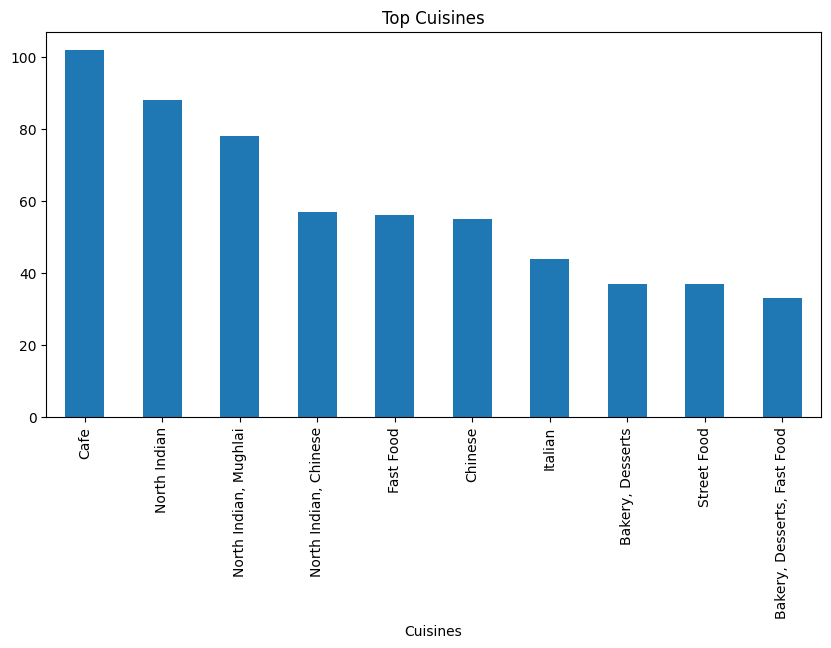

In [ ]:
import matplotlib.pyplot as plt

df['Cuisines'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Cuisines")
plt.show()


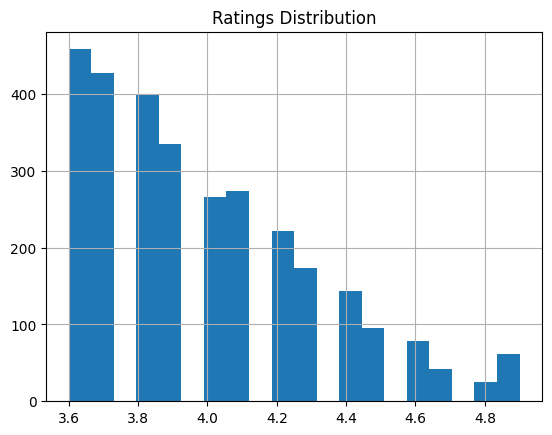

In [ ]:
df['Aggregate rating'].hist(bins=20)

plt.title("Ratings Distribution")
plt.show()